<a href="https://colab.research.google.com/github/andreaeddyricci/COVID_Visualizations/blob/main/covid_data_integration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
! pip install sodapy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import requests
import glob
import io
import requests
import calendar
import time

# CDC data API
from sodapy import Socrata

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# GOOGLE DRIVE SETUP INSTRUCTIONS
# 1) have access to the team drive
# 2) go to 'shared with me' on your google drive and find the project folder
# 3) right click on it, click 'add shortcut', and put the shortcut in 'My Drive'
# 4) you are all set!  My drive pathing works for everyone now

Mounted at /content/drive


# JHU Data Pull via API

Data was pulled via The [JHU webside covid data api / json file](https://jhucoronavirus.azureedge.net/api/v1/testing/daily.json)

In [ ]:
filename = '/content/drive/MyDrive/593: Milestone 1 COVID/jhu_daily_covid_data.json'

jhu_raw = pd.read_json(filename)
jhu_raw['date'] = pd.to_datetime(jhu_raw['date'], format = '%Y%m%d' )  # convert the dtype of date from an integer to a date
print(jhu_raw.shape)
print(jhu_raw.dtypes.sort_index())
jhu_raw.head()

(36628, 14)
cases_conf_probable               float64
cases_confirmed                   float64
cases_probable                    float64
date                       datetime64[ns]
encounters_viral_total            float64
people_antigen_positive           float64
people_antigen_total              float64
people_viral_positive             float64
people_viral_total                float64
state                              object
tests_combined_total              float64
tests_viral_negative              float64
tests_viral_positive              float64
tests_viral_total                 float64
dtype: object


,date,state,people_viral_positive,tests_viral_positive,tests_viral_negative,encounters_viral_total,tests_viral_total,people_viral_total,tests_combined_total,cases_conf_probable,people_antigen_positive,people_antigen_total,cases_confirmed,cases_probable
0,2020-03-06,AK,NaN,NaN,NaN,NaN,8.0,NaN,8.0,NaN,NaN,NaN,NaN,NaN
1,2020-03-07,AK,NaN,NaN,NaN,NaN,12.0,NaN,12.0,NaN,NaN,NaN,NaN,NaN
2,2020-03-08,AK,NaN,NaN,NaN,NaN,14.0,NaN,14.0,NaN,NaN,NaN,NaN,NaN
3,2020-03-09,AK,NaN,NaN,NaN,NaN,23.0,NaN,23.0,NaN,NaN,NaN,NaN,NaN
4,2020-03-10,AK,NaN,NaN,NaN,NaN,23.0,NaN,23.0,NaN,NaN,NaN,NaN,NaN


# Pull the rest of JHU data via CSV

Looks like the JHU .json file didn't have data past 2021, this CSV has data through 2022, so we will pull the remaining data from this csv.  Additionally, we have 2 extra columns that we want to

In [ ]:
filename = '/content/drive/MyDrive/593: Milestone 1 COVID/jhu_time_series_covid19_US.csv'

jhu_ts_us_raw = pd.read_csv(filename)  # load in the csv
jhu_ts_us_raw['date'] = pd.to_datetime(jhu_ts_us_raw['date'])  # convert the date column to datetime, this is already formatted like a date so no extra parameter sneeded
print(jhu_ts_us_raw.shape)
print(jhu_ts_us_raw.dtypes.sort_index()) #sort the index to return columns in alphabetical order
jhu_ts_us_raw.head()

(52252, 16)
cases_conf_probable               float64
cases_confirmed                   float64
cases_probable                    float64
date                       datetime64[ns]
encounters_viral_total            float64
people_antigen_positive           float64
people_antigen_total              float64
people_viral_positive             float64
people_viral_total                float64
state                              object
tests_antigen_positive            float64
tests_antigen_total               float64
tests_combined_total              float64
tests_viral_negative              float64
tests_viral_positive              float64
tests_viral_total                 float64
dtype: object


,date,state,cases_conf_probable,cases_confirmed,cases_probable,tests_viral_positive,tests_viral_negative,tests_viral_total,tests_antigen_positive,tests_antigen_total,people_viral_positive,people_viral_total,people_antigen_positive,people_antigen_total,encounters_viral_total,tests_combined_total
0,2020-03-06,AK,NaN,NaN,NaN,0.0,27.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.0
1,2020-03-07,AK,NaN,NaN,NaN,0.0,32.0,32.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.0
2,2020-03-08,AK,NaN,NaN,NaN,0.0,40.0,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.0
3,2020-03-09,AK,NaN,NaN,NaN,0.0,59.0,59.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.0
4,2020-03-10,AK,NaN,NaN,NaN,0.0,76.0,76.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.0


## Merge JHU JSON data with JHU COVID data

We can merge everything together using a full outer join to combine the data.  That way both tables can replace missing rows.  for example if for Washington, JHU JSON has 2021-01-13 but is missing 2021-01-14, and the JHU CSV has 2021-01-14 but not 2021-01-13, a full outer join would pull the respective rows from each dataframe to combine them.

In [ ]:
shared_columns = ['date','state','people_viral_positive','tests_viral_positive',
                  'tests_viral_negative','encounters_viral_total','tests_viral_total',
                  'people_viral_total','tests_combined_total','cases_conf_probable',
                  'people_antigen_positive','people_antigen_total','cases_confirmed','cases_probable']
combined_jhu = pd.merge(jhu_raw, jhu_ts_us_raw, on = shared_columns, how = 'outer').sort_values(['date','state'])
print(combined_jhu.shape)
combined_jhu.head()

(61048, 16)


,date,state,people_viral_positive,tests_viral_positive,tests_viral_negative,encounters_viral_total,tests_viral_total,people_viral_total,tests_combined_total,cases_conf_probable,people_antigen_positive,people_antigen_total,cases_confirmed,cases_probable,tests_antigen_positive,tests_antigen_total
0,2020-01-13,WA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-14,WA,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-15,WA,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-16,WA,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-17,WA,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN


However, this has the problem that there are duplicates in our data if both datasets had rows in them, as NaN is not treated as an equivalent or overwritten when joining.  By taking the value_counts of the combination of (Date, State), we can determine how many times there are duplicates and how often it happens.  Overall, we find that there is a 16.8% duplicate rate and the most times we have duplicates is twice (2 rows)

In [ ]:
print(combined_jhu[['date','state']].value_counts().mean())  # problem, we have duplicates, need to de-duplicate
print(combined_jhu[['date','state']].value_counts().max()) # how bad is our duplication problem?

1.1683380540457782
2


### Fix JHU data duplicates
There is an easy way to fix this NaN joining problem, we can group by State and Date columns to aggregate down the duplicates.  An easy way to handle this is to aggregate on MEAN, as for mean:

*   MEAN (value, NAN) = value
*   MEAN (value, value) = value
*   MEAN (value1, value2) = average of values.  This shouldn't happen but gets us an average, and also might yield the real value if the 'mismatched values' are due to a floating point error.
*   MEAN (NAN, NAN) = NAN, if both are NAN, we keep it as NAN



In [ ]:
combined_jhu_deduped = combined_jhu.groupby(['date','state']).mean().reset_index()
combined_jhu_deduped.head()

,date,state,people_viral_positive,tests_viral_positive,tests_viral_negative,encounters_viral_total,tests_viral_total,people_viral_total,tests_combined_total,cases_conf_probable,people_antigen_positive,people_antigen_total,cases_confirmed,cases_probable,tests_antigen_positive,tests_antigen_total
0,2020-01-13,WA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-14,WA,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-15,WA,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-16,WA,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-17,WA,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
combined_jhu_deduped.groupby('state').agg(min_dt = ('date','min'), max_dt = ('date','max'), ct = ('state','count'))

,min_dt,max_dt,ct
state,,,
AK,2020-03-06,2022-09-20,929
AL,2020-03-07,2022-09-20,928
AR,2020-03-06,2022-09-20,929
AS,2020-03-16,2022-09-20,919
AZ,2020-03-04,2022-09-20,931
CA,2020-03-04,2022-09-20,931
CO,2020-03-04,2022-09-20,931
CT,2020-02-29,2022-09-20,935
DC,2020-03-05,2022-09-20,930


# Pull In Hospitalization Data

Now that we have our JHU covid test data neatly in 1 place, we now can pull hosputalization data.  In my mind it makes more sense to get the daily data cleaned versions first, and then figure out how to aggregate them to a monthly level and combine them for use elsewhere

In [ ]:
# Source: https://dev.socrata.com/foundry/data.cdc.gov/6jg4-xsqq
client = Socrata("data.cdc.gov", None)

# Example authenticated client (needed for non-public datasets):
# client = Socrata(data.cdc.gov,
#                  MyAppToken,
#                  username="user@example.com",
#                  password="AFakePassword")

# First 2000 results, returned as JSON from API / converted to Python list of
# dictionaries by sodapy.
results = client.get("6jg4-xsqq", limit=210000)

# Convert to pandas DataFrame
cdc_hospital_data = pd.DataFrame.from_records(results)
### Convert Hospital data dtypes
cdc_hospital_data['week_ending_date'] = pd.to_datetime(cdc_hospital_data['week_ending_date'])
cdc_hospital_data['weekly_rate'] = pd.to_numeric(cdc_hospital_data['weekly_rate'])
cdc_hospital_data['cumulative_rate'] = pd.to_numeric(cdc_hospital_data['cumulative_rate'])
# Rename our rate columns to be more descriptive
cdc_hospital_data = cdc_hospital_data.rename(columns = {'weekly_rate':'weekly_hospitalization_rate_per_100k', 'cumulative_rate':'cumulative_hospitalization_rate_per_100k'})
print(cdc_hospital_data.shape)
print(cdc_hospital_data.dtypes)
cdc_hospital_data.head()

(209098, 9)
state                                               object
season                                              object
week_ending_date                            datetime64[ns]
agecat_label                                        object
sex_label                                           object
race_label                                          object
rate_type                                           object
weekly_hospitalization_rate_per_100k               float64
cumulative_hospitalization_rate_per_100k           float64
dtype: object


,state,season,week_ending_date,agecat_label,sex_label,race_label,rate_type,weekly_hospitalization_rate_per_100k,cumulative_hospitalization_rate_per_100k
0,CA,2019-20,2020-03-07,0-4 years,All,All,Observed,0.0,0.0
1,CA,2019-20,2020-03-14,0-4 years,All,All,Observed,0.0,0.0
2,CA,2019-20,2020-03-21,0-4 years,All,All,Observed,0.0,0.0
3,CA,2019-20,2020-03-28,0-4 years,All,All,Observed,0.5,0.5
4,CA,2019-20,2020-04-04,0-4 years,All,All,Observed,0.0,0.5


## Filter hospitalization data to be more generalized

Hospitalization data has several extra variables that we do not wish to include in our analysis, mainly because they would provide more granualirty than the google trends data can provide.  To filter towards a more generalized set to match google, we will:


*   Trim data after 2022 because there is no more testing data
*   filter  `agecat_label` to 'All'
*   filter  `sex_label` to 'All'
*   filter  `race_label` to 'All'
*   filter  `rate_type` to 'Observed' to remove the age adjusted rates

As we wish to have aggregated results to match the level of granualrity of google



In [ ]:
cdc_hospital_data_filtered = cdc_hospital_data.query(""" agecat_label == 'All' & sex_label == 'All' & race_label == 'All' & rate_type == 'Observed'""")
cdc_hospital_data_filtered = cdc_hospital_data_filtered[cdc_hospital_data_filtered['week_ending_date'] < '2022-10-01']  # use this to match covid test data ending in 2022-09
cdc_hospital_data_filtered.head()

,state,season,week_ending_date,agecat_label,sex_label,race_label,rate_type,weekly_hospitalization_rate_per_100k,cumulative_hospitalization_rate_per_100k
870,CA,2019-20,2020-03-07,All,All,All,Observed,0.2,0.2
871,CA,2019-20,2020-03-14,All,All,All,Observed,0.7,0.9
872,CA,2019-20,2020-03-21,All,All,All,Observed,2.1,3.0
873,CA,2019-20,2020-03-28,All,All,All,Observed,3.6,6.6
874,CA,2019-20,2020-04-04,All,All,All,Observed,3.7,10.4


In [ ]:
cdc_hospital_data_filtered.groupby('state').agg(weeks = ('week_ending_date','count'), min_dt = ('week_ending_date','min'), max_dt = ('week_ending_date','max'))  # check data availability

,weeks,min_dt,max_dt
state,,,
CA,134,2020-03-07,2022-09-24
CO,134,2020-03-07,2022-09-24
COVID-NET,134,2020-03-07,2022-09-24
CT,134,2020-03-07,2022-09-24
GA,134,2020-03-07,2022-09-24
IA,116,2020-03-07,2022-05-21
MD,134,2020-03-07,2022-09-24
MI,134,2020-03-07,2022-09-24
MN,134,2020-03-07,2022-09-24


# Convert all of our data to be on a monthly basis

In [ ]:
combined_jhu_deduped['year_month'] = combined_jhu_deduped['date'].dt.to_period('M').dt.to_timestamp()#  take data column, extract data, cast it to month, take the date, convert to timestamp
cdc_hospital_data_filtered['year_month'] = cdc_hospital_data_filtered['week_ending_date'].dt.to_period('M').dt.to_timestamp()

# Aggregate all of our data at the monthly level


*   Testing data gets SUMMED as it is a raw value
*   Hospitalization data is an AVERAGE as it is a rate



In [ ]:
combined_jhu_agg = combined_jhu_deduped.drop(columns = 'date').groupby(['year_month','state']).max().reset_index()  # remove date as we have year_month, then group by and take the sum
cdc_hospital_data_agg = cdc_hospital_data_filtered.drop(columns = ['week_ending_date','season','agecat_label','sex_label','race_label','rate_type'])\
                                                  .groupby(['year_month','state']).agg(
                                                      weekly_hospitalization_rate_per_100k = ('weekly_hospitalization_rate_per_100k','mean'), # take the MEAN weekly average rate for the monthly avg
                                                      cumulative_hospitalization_rate_per_100k = ('cumulative_hospitalization_rate_per_100k','max')  # taxe the MAX cumulatie hospitalization rate to get the rate at the end of the month
                                                  ).reset_index()

In [ ]:
combined_jhu_agg.head()

,year_month,state,people_viral_positive,tests_viral_positive,tests_viral_negative,encounters_viral_total,tests_viral_total,people_viral_total,tests_combined_total,cases_conf_probable,people_antigen_positive,people_antigen_total,cases_confirmed,cases_probable,tests_antigen_positive,tests_antigen_total
0,2020-01-01,FL,NaN,NaN,NaN,4.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-01,MA,NaN,1.0,NaN,NaN,4.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-01,VA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2.0
3,2020-01-01,WA,2.0,NaN,NaN,0.0,NaN,NaN,0.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-02-01,CT,NaN,0.0,3.0,NaN,3.0,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cdc_hospital_data_agg.head()

,year_month,state,weekly_hospitalization_rate_per_100k,cumulative_hospitalization_rate_per_100k
0,2020-03-01,CA,1.650,6.6
1,2020-03-01,CO,5.375,21.5
2,2020-03-01,COVID-NET,2.800,11.3
3,2020-03-01,CT,6.325,25.4
4,2020-03-01,GA,5.900,23.5


## for JHU data, add a US aggreagte value

In [ ]:
us_agg = combined_jhu_agg.groupby('year_month').sum().reset_index()  # take the sum across all states for each month
us_agg['state'] = 'COVID-NET'  # rename to 'COVID-NET' to match CDC data

combined_jhu_agg_w_usa = pd.concat([combined_jhu_agg, us_agg])  # join JHU data with theUSA level JHU data

## Merge JHU and CDC data

In [ ]:
combined_jhu_cdc = pd.merge(combined_jhu_agg_w_usa, cdc_hospital_data_agg, on = ['year_month','state'], how = 'left')
combined_jhu_cdc.sort_values(by = ['state','year_month']).head()

,year_month,state,people_viral_positive,tests_viral_positive,tests_viral_negative,encounters_viral_total,tests_viral_total,people_viral_total,tests_combined_total,cases_conf_probable,people_antigen_positive,people_antigen_total,cases_confirmed,cases_probable,tests_antigen_positive,tests_antigen_total,weekly_hospitalization_rate_per_100k,cumulative_hospitalization_rate_per_100k
12,2020-03-01,AK,128.0,214.0,7647.0,NaN,5788.0,NaN,5788.0,128.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
68,2020-04-01,AK,355.0,465.0,24053.0,NaN,21828.5,NaN,21828.5,355.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
124,2020-05-01,AK,463.0,620.0,61072.0,NaN,56707.0,NaN,56707.0,463.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
180,2020-06-01,AK,944.0,1383.0,148930.0,NaN,131289.5,NaN,131289.5,944.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
236,2020-07-01,AK,2993.0,4455.0,289635.0,NaN,263703.5,NaN,263703.5,2993.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
combined_jhu_cdc.groupby('state').agg(min_dt = ('year_month','min'), max_dt = ('year_month','max'), ct = ('state','count'))

,min_dt,max_dt,ct
state,,,
AK,2020-03-01,2022-09-01,31
AL,2020-03-01,2022-09-01,31
AR,2020-03-01,2022-09-01,31
AS,2020-03-01,2022-09-01,31
AZ,2020-03-01,2022-09-01,31
CA,2020-03-01,2022-09-01,31
CO,2020-03-01,2022-09-01,31
COVID-NET,2020-01-01,2022-09-01,33
CT,2020-02-01,2022-09-01,32


## Add Monthly difference columns for JHU data:

JHU data is cumulative, so we will now use pandas .diff() to convert those cumulative totals back to Month Over Month values

In [ ]:
combined_jhu_cdc_sorted = combined_jhu_cdc.sort_values(by = ['state','year_month'])  # sort our data by state and date to make .diff work correctly
cols_to_diff_names = combined_jhu_agg.columns.tolist()[2:] # take all JHU columns AFTER state & Date
monthly_column_names = []
for name in cols_to_diff_names:
  monthly_column_names.append(name+'_monthly')
print(cols_to_diff_names)
print(monthly_column_names)
combined_jhu_cdc_sorted[monthly_column_names] = combined_jhu_cdc_sorted.groupby('state')[cols_to_diff_names].diff()

# diff needs a previous value, so we have to fill the first row of data from the cumulative totals
for name in cols_to_diff_names:
  combined_jhu_cdc_sorted[name+'_monthly'] = combined_jhu_cdc_sorted[name+'_monthly'].fillna(combined_jhu_cdc_sorted[name])  # fill nulls in monthly fom cumulative.  Because of diff(), the only nan values that aren't shared with

['people_viral_positive', 'tests_viral_positive', 'tests_viral_negative', 'encounters_viral_total', 'tests_viral_total', 'people_viral_total', 'tests_combined_total', 'cases_conf_probable', 'people_antigen_positive', 'people_antigen_total', 'cases_confirmed', 'cases_probable', 'tests_antigen_positive', 'tests_antigen_total']
['people_viral_positive_monthly', 'tests_viral_positive_monthly', 'tests_viral_negative_monthly', 'encounters_viral_total_monthly', 'tests_viral_total_monthly', 'people_viral_total_monthly', 'tests_combined_total_monthly', 'cases_conf_probable_monthly', 'people_antigen_positive_monthly', 'people_antigen_total_monthly', 'cases_confirmed_monthly', 'cases_probable_monthly', 'tests_antigen_positive_monthly', 'tests_antigen_total_monthly']


### Test if monthly data is working

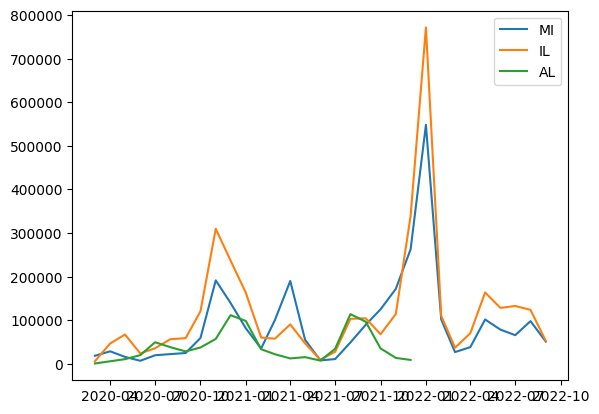

In [ ]:
subset_df = combined_jhu_cdc_sorted[combined_jhu_cdc_sorted['state']== 'MI']
plt.plot(subset_df['year_month'], subset_df['cases_conf_probable_monthly'], label = 'MI')
subset_df = combined_jhu_cdc_sorted[combined_jhu_cdc_sorted['state']== 'IL']
plt.plot(subset_df['year_month'], subset_df['cases_conf_probable_monthly'], label = 'IL')
subset_df = combined_jhu_cdc_sorted[combined_jhu_cdc_sorted['state']== 'AL']
plt.plot(subset_df['year_month'], subset_df['cases_conf_probable_monthly'], label = 'AL')
plt.legend()

# Export data

In [ ]:

# rename columns for easier naming conventions
combined_jhu_cdc_sorted = combined_jhu_cdc_sorted.rename(columns = {'state':'State Abbreviation'})
combined_jhu_cdc_sorted.to_csv('/content/drive/MyDrive/593: Milestone 1 COVID/jhu_cdc_covid_clean.csv', index=False)

## View Cases Data

In [ ]:
print(combined_jhu_cdc_sorted.columns)
var = 'cases_conf_probable'
combined_jhu_cdc_sorted[combined_jhu_cdc_sorted['State Abbreviation'] == 'AL'][['State Abbreviation','year_month',var,var+'_monthly']]

Index(['year_month', 'State Abbreviation', 'people_viral_positive',
       'tests_viral_positive', 'tests_viral_negative',
       'encounters_viral_total', 'tests_viral_total', 'people_viral_total',
       'tests_combined_total', 'cases_conf_probable',
       'people_antigen_positive', 'people_antigen_total', 'cases_confirmed',
       'cases_probable', 'tests_antigen_positive', 'tests_antigen_total',
       'weekly_hospitalization_rate_per_100k',
       'cumulative_hospitalization_rate_per_100k',
       'people_viral_positive_monthly', 'tests_viral_positive_monthly',
       'tests_viral_negative_monthly', 'encounters_viral_total_monthly',
       'tests_viral_total_monthly', 'people_viral_total_monthly',
       'tests_combined_total_monthly', 'cases_conf_probable_monthly',
       'people_antigen_positive_monthly', 'people_antigen_total_monthly',
       'cases_confirmed_monthly', 'cases_probable_monthly',
       'tests_antigen_positive_monthly', 'tests_antigen_total_monthly'],
      dtyp

,State Abbreviation,year_month,cases_confirmed,cases_confirmed_monthly
13,AL,2020-03-01,NaN,NaN
69,AL,2020-04-01,NaN,NaN
125,AL,2020-05-01,NaN,NaN
181,AL,2020-06-01,NaN,NaN
237,AL,2020-07-01,NaN,NaN
293,AL,2020-08-01,NaN,NaN
349,AL,2020-09-01,NaN,NaN
405,AL,2020-10-01,NaN,NaN
461,AL,2020-11-01,NaN,NaN
517,AL,2020-12-01,NaN,NaN


# Weather Data Pull via API

In [ ]:
# NOAA state IDs
state_ids = {
    "Alabama": 1, "Arizona": 2, "Arkansas": 3,
    "California": 4, "Colorado": 5, "Connecticut": 6,
    "Delaware": 7, "Florida": 8, "Georgia": 9,
    "Idaho": 10, "Illinois": 11, "Indiana": 12,
    "Iowa": 13, "Kansas": 14, "Kentucky": 15,
    "Louisiana": 16, "Maine": 17, "Maryland": 18,
    "Massachusetts": 19, "Michigan": 20,
    "Minnesota": 21, "Mississippi": 22,
    "Missouri": 23, "Montana": 24,
    "Nebraska": 25, "Nevada": 26,
    "New Hampshire": 27, "New Jersey": 28,
    "New Mexico": 29, "New York": 30,
    "North Carolina": 31, "North Dakota": 32,
    "Ohio": 33, "Oklahoma": 34,
    "Oregon": 35, "Pennsylvania": 36,
    "Rhode Island": 37, "South Carolina": 38,
    "South Dakota": 39, "Tennessee": 40,
    "Texas": 41, "Utah": 42,
    "Vermont": 43, "Virginia": 44,
    "Washington": 45, "West Virginia": 46,
    "Wisconsin": 47, "Wyoming": 48
}

start_year = 2020
end_year = 2022

weather_rows = []

# loop through all states
for state, state_id in state_ids.items():

    for month in range(1, 13):

        url = (
            f"https://www.ncei.noaa.gov/access/monitoring/"
            f"climate-at-a-glance/statewide/time-series/"
            f"{state_id}/tavg/1/{month}/"
            f"{start_year}-{end_year}.json"
        )

        response = requests.get(url)

        if response.status_code == 200:

            data = response.json()["data"]

            for date_code, values in data.items():

                weather_rows.append({
                    "year_month": pd.Timestamp(
                                  year=int(date_code[:4]),
                                  month=int(date_code[4:]),
                                  day=1),
                    "state": state,
                    "state_id": state_id,
                    "year": int(date_code[:4]),
                    "month": int(date_code[4:]),
                    "month_name": calendar.month_name[int(date_code[4:])],
                    "avg_temp_f": float(values["value"])
                })

        time.sleep(0.1)   # avoid hammering NOAA

df_weather = pd.DataFrame(weather_rows)
df_weather.to_csv('/content/drive/MyDrive/593: Milestone 1 COVID/weather.csv', index=False)